In [1]:
##Importing all the required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
from scipy.stats import chi2_contingency
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
import string
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
##Reading input file
file_path = 'HR Analytics Assignment.csv'
df = pd.read_csv(file_path)

In [ ]:
##Checking for dupliacte rows if any
duplicates = df[df.duplicated()]
print("Duplicate Rows:")
print(duplicates)
num_duplicates = len(duplicates)

Duplicate Rows:
Empty DataFrame
Columns: [EmpID, Location, Gender, Level, Date Of Joining, Overall Rating, Career Growth, Compensation and Benefits, Work-life Balance, Comments]
Index: []


In [4]:
df.describe()

,EmpID,Location,Gender,Level,Date Of Joining,Overall Rating,Career Growth,Compensation and Benefits,Work-life Balance,Comments
count,25866,25831,25831,25831,25866,25866,25866,25866,25866,25807
unique,25866,8,4,4,6975,5,5,5,5,17470
top,a80b49x693,LocE,Men,Junior,01-Mar-17,Satisfied,Very Satisfied,Neutral,Very Satisfied,0
freq,1,3342,13449,14609,15,8461,8564,7199,8403,2306


In [ ]:
##Checking for null values
df.isnull().sum()

EmpID                         0
Location                     35
Gender                       35
Level                        35
Date Of Joining               0
Overall Rating                0
Career Growth                 0
Compensation and Benefits     0
Work-life Balance             0
Comments                     59
dtype: int64

In [6]:
df['Date Of Joining'] = pd.to_datetime(df['Date Of Joining'])

C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_2892\2679818189.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Of Joining'] = pd.to_datetime(df['Date Of Joining'])


In [7]:
df_missing_percent = df.isnull().sum()/len(df)
df_missing_percent

EmpID                        0.000000
Location                     0.001353
Gender                       0.001353
Level                        0.001353
Date Of Joining              0.000000
Overall Rating               0.000000
Career Growth                0.000000
Compensation and Benefits    0.000000
Work-life Balance            0.000000
Comments                     0.002281
dtype: float64

In [8]:
##Question 1
contingency_table = pd.crosstab(df['Location'], df['Overall Rating'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-Square Statistic: 41.98224351113883
P-value: 0.04352616592278983
Degrees of Freedom: 28
Expected Frequencies:
[[ 226.70434749  580.26402385 1046.92810964  311.5636251  1034.53989393]
 [ 224.15392358  573.73605358 1035.1501684   308.05853432 1022.90132012]
 [ 225.49998064  577.18137122 1041.36630405  309.90844334 1029.04390074]
 [ 227.12941814  581.35201889 1048.89109984  312.1478069  1036.47965623]
 [ 236.76435291  606.01323991 1093.3855445   325.38926097 1080.44760172]
 [ 233.00956215  596.40261701 1076.04579768  320.22898842 1063.31303473]
 [ 223.30378228  571.56006349 1031.22418799  306.89017073 1019.02179552]
 [ 233.43463281  597.49061206 1078.00878789  320.81317022 1065.25279703]]


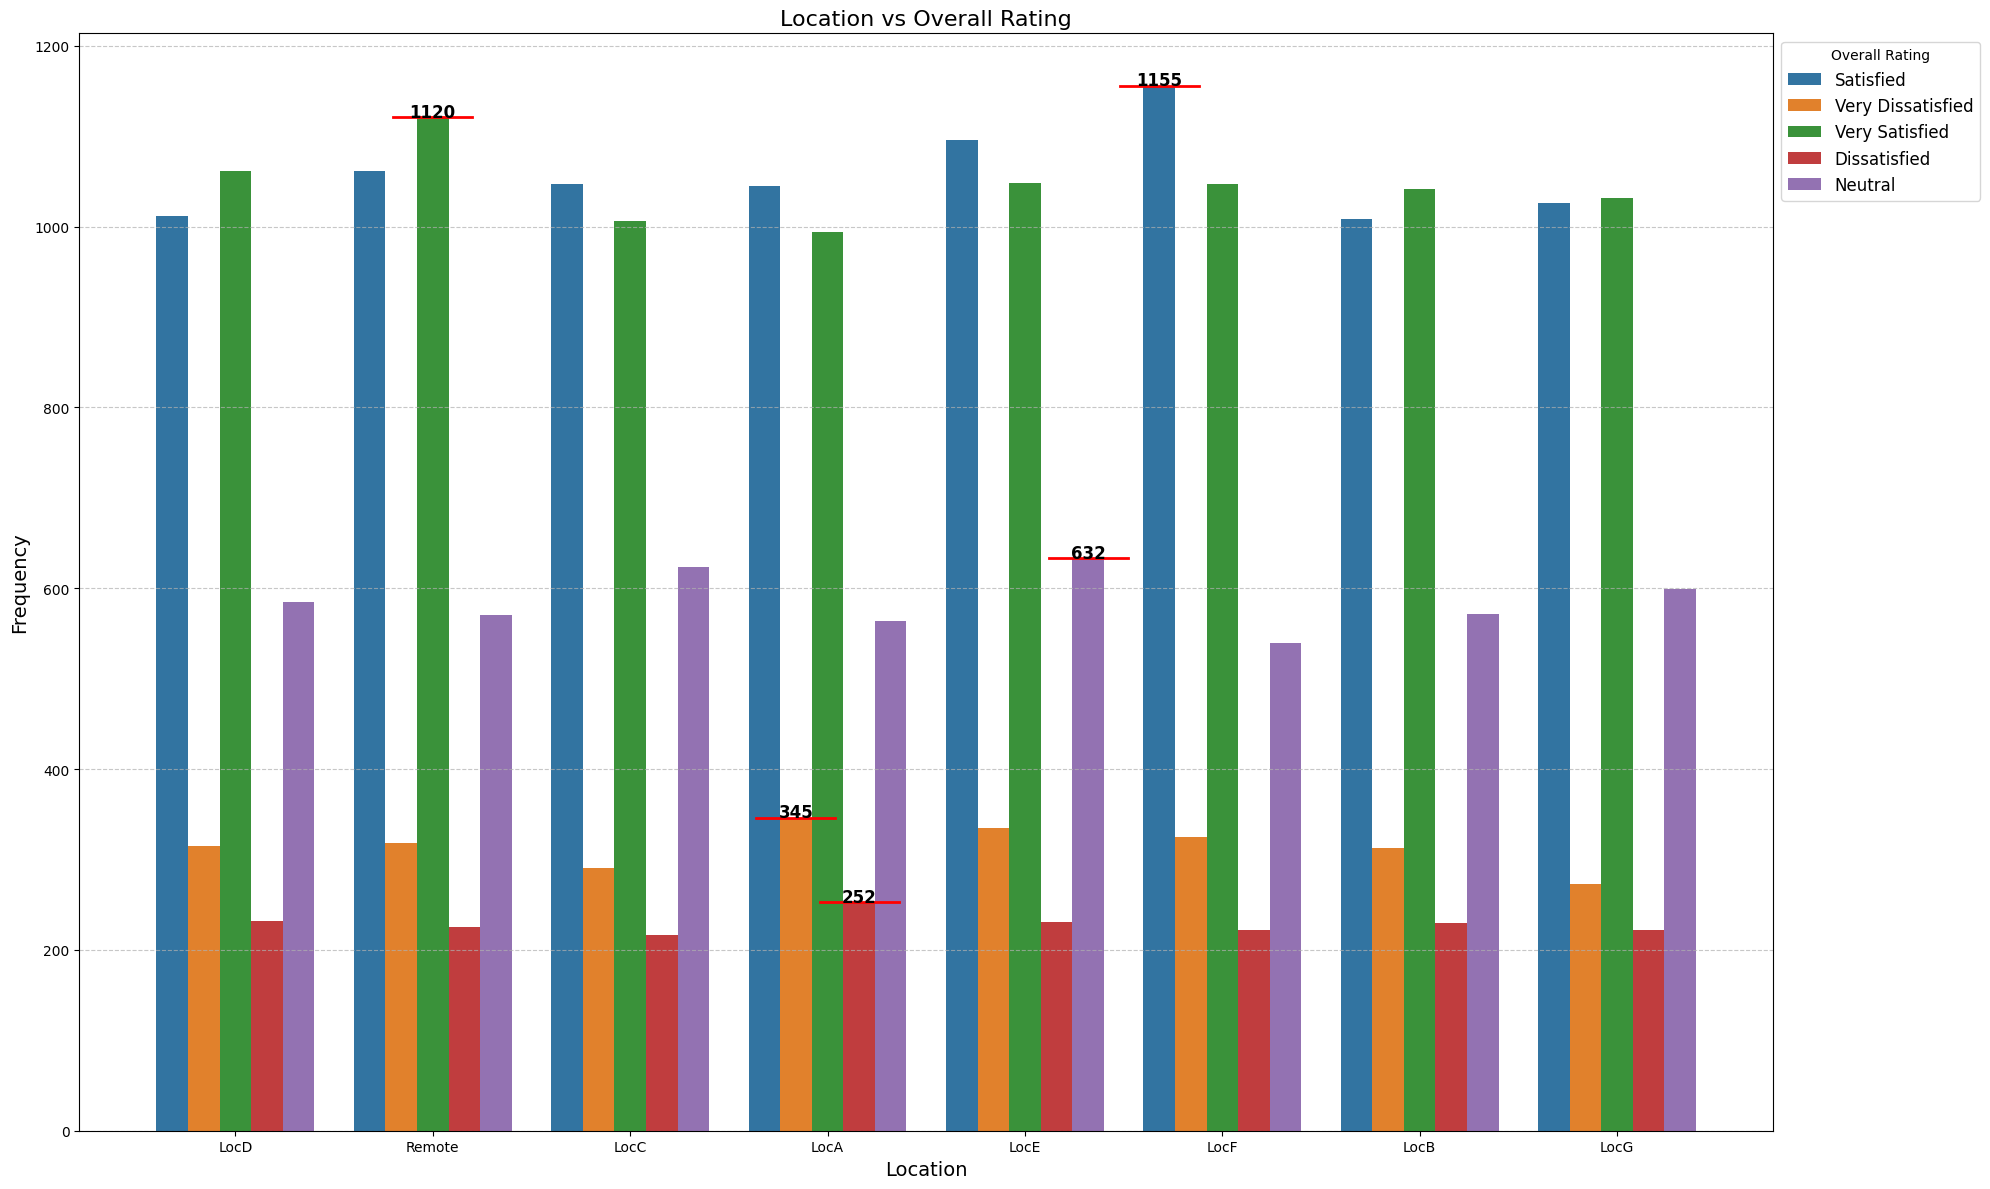

In [9]:
##Plot for Location vs Overall Rating
plt.figure(figsize=(20, 12))
ax = sns.countplot(data=df, x='Location', hue='Overall Rating')
for container in ax.containers:  
    heights = [bar.get_height() for bar in container]
    
    max_height = max(heights)
    max_index = heights.index(max_height)
    
    x = container[max_index].get_x() + container[max_index].get_width() / 2
    ax.plot([x - 0.2, x + 0.2], [max_height + 1, max_height + 1], color='red', lw=2)
    ax.text(
        x,
        max_height + 1.5,
        f"{int(max_height)}",
        ha="center",
        fontsize=12,
        color="black",
        weight="bold",
    )
plt.title('Location vs Overall Rating', fontsize=16)
plt.xlabel('Location', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Overall Rating', loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

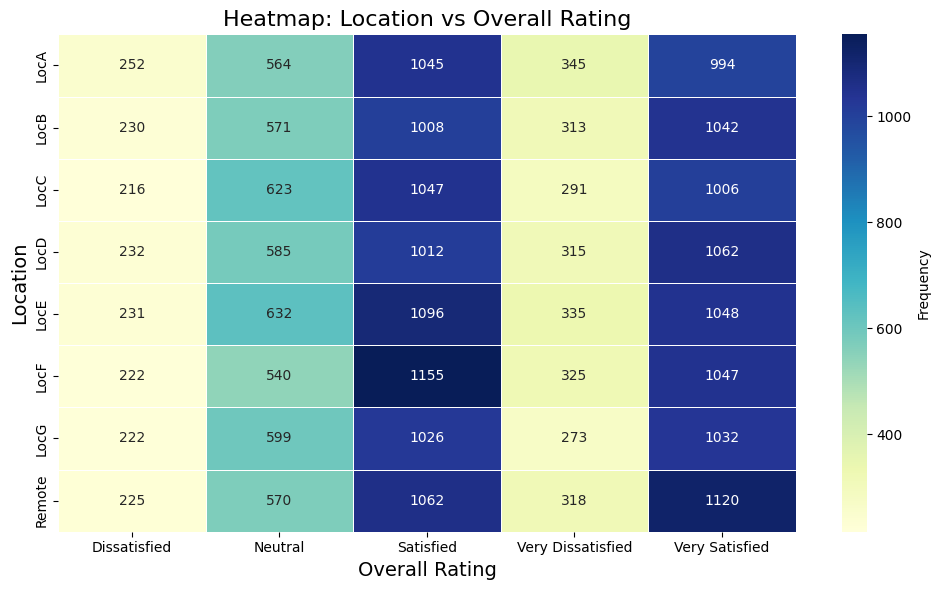

In [10]:
##Heatmap for location vs overall rating
heatmap_data = pd.crosstab(df['Location'], df['Overall Rating'])
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,          
    fmt="d",             
    cmap="YlGnBu",       
    linewidths=0.5,      
    cbar_kws={'label': 'Frequency'} 
)
plt.title("Heatmap: Location vs Overall Rating", fontsize=16)
plt.xlabel("Overall Rating", fontsize=14)
plt.ylabel("Location", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_2892\1485247674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=very_dissatisfied_data, x='Location', palette='Reds')


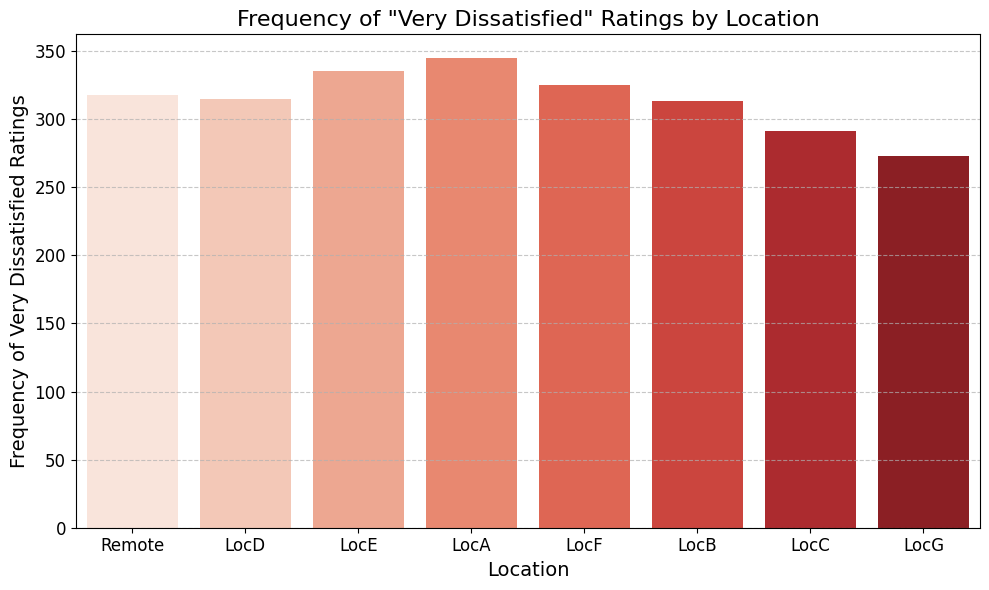

In [11]:
##Plot for "very dissatisfied" with respect to location
very_dissatisfied_data = df[df['Overall Rating'] == 'Very Dissatisfied']
plt.figure(figsize=(10, 6))
sns.countplot(data=very_dissatisfied_data, x='Location', palette='Reds')
plt.title('Frequency of "Very Dissatisfied" Ratings by Location', fontsize=16)
plt.xlabel('Location', fontsize=14)
plt.ylabel('Frequency of Very Dissatisfied Ratings', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_2892\2199610935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=very_satisfied_data, x='Location', palette='Reds')


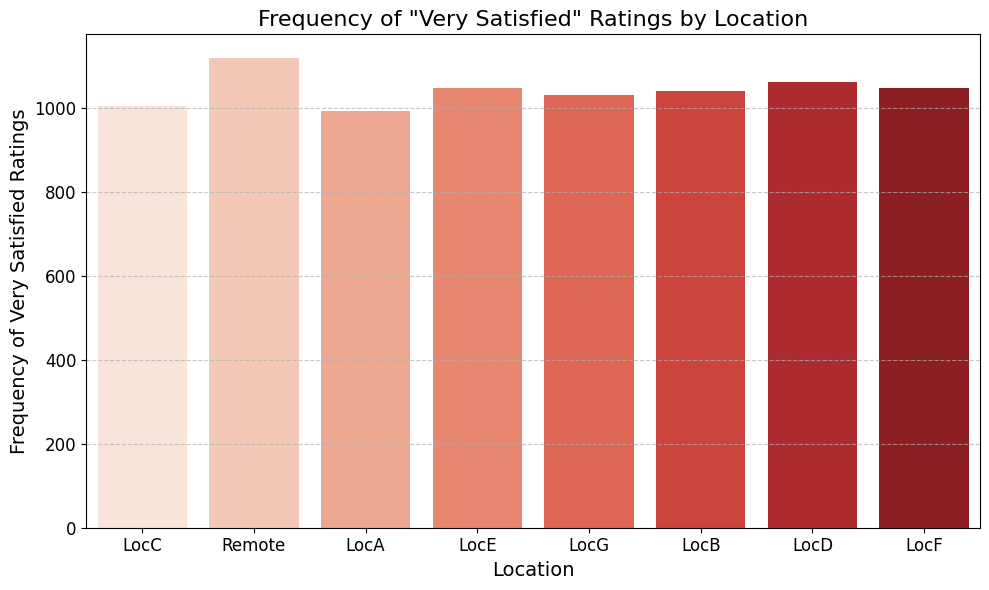

In [12]:
##Plot for "very satisfied" with respect to location
very_satisfied_data = df[df['Overall Rating'] == 'Very Satisfied']
plt.figure(figsize=(10, 6))
sns.countplot(data=very_satisfied_data, x='Location', palette='Reds')
plt.title('Frequency of "Very Satisfied" Ratings by Location', fontsize=16)
plt.xlabel('Location', fontsize=14)
plt.ylabel('Frequency of Very Satisfied Ratings', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
##Gender vs Overall Rating
contingency_table = pd.crosstab(df['Gender'], df['Overall Rating'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-Square Statistic: 165.26931293453507
P-value: 4.4219160693293827e-29
Degrees of Freedom: 12
Expected Frequencies:
[[9.52795865e+02 2.43874089e+03 4.40004255e+03 1.30944350e+03
  4.34797720e+03]
 [9.20986412e-01 2.35732260e+00 4.25314545e+00 1.26572723e+00
  4.20281832e+00]
 [5.89431303e+01 1.50868646e+02 2.72201309e+02 8.10065425e+01
  2.68980372e+02]
 [8.17340018e+02 2.09203314e+03 3.77450300e+03 1.12328423e+03
  3.72983961e+03]]


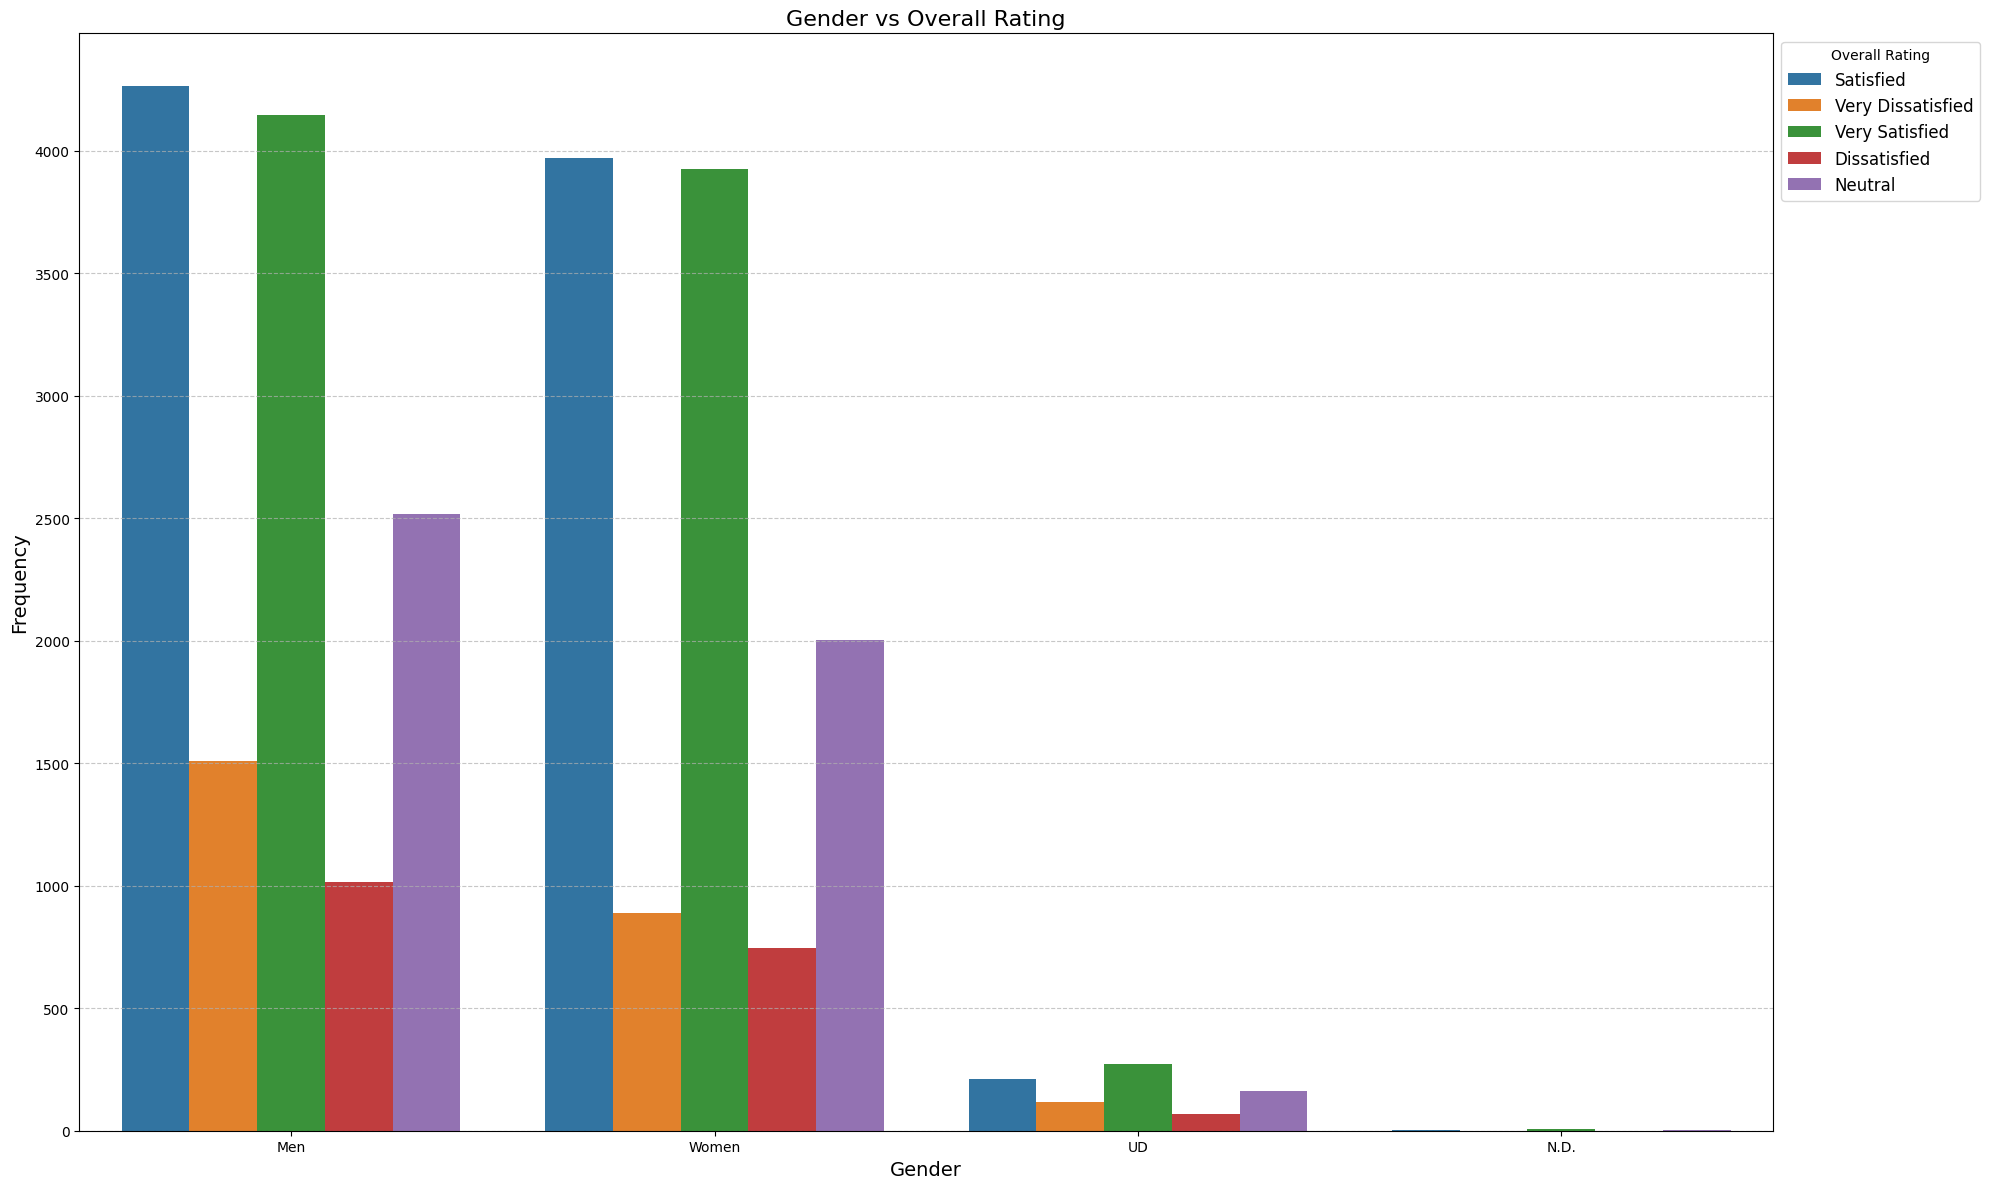

In [14]:
##Plot for Gender vs Overall Rating   
plt.figure(figsize=(20,12))
sns.countplot(data=df, x='Gender', hue='Overall Rating')
plt.title('Gender vs Overall Rating', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Overall Rating', loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  
plt.show()

C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_2892\2155075239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=very_satisfied_data, x='Gender', palette='Reds')


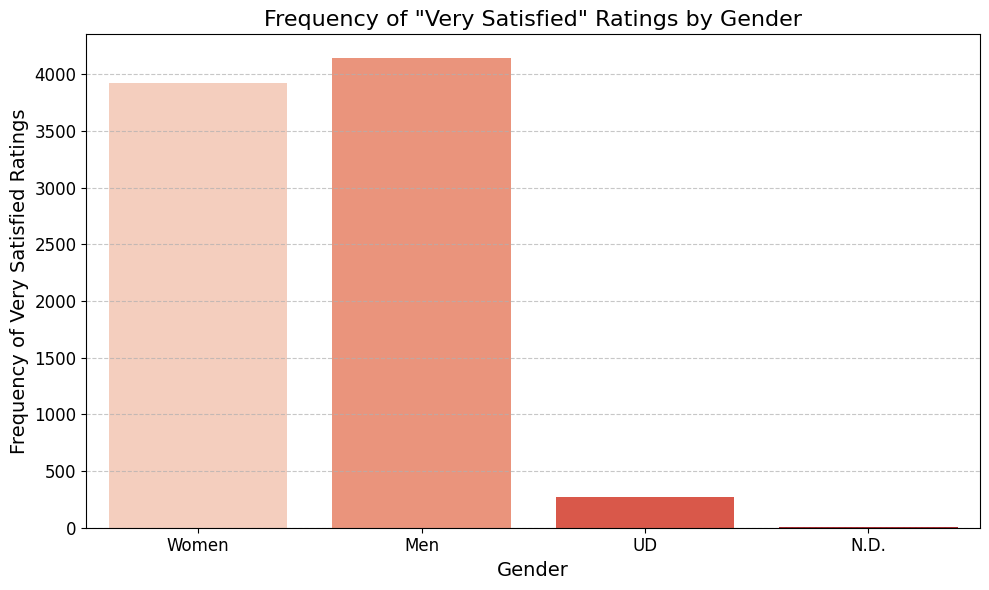

In [15]:
##Plot for "Very Satisfied" with respect to Gender
very_satisfied_data = df[df['Overall Rating'] == 'Very Satisfied']
plt.figure(figsize=(10, 6))
sns.countplot(data=very_satisfied_data, x='Gender', palette='Reds')
plt.title('Frequency of "Very Satisfied" Ratings by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Frequency of Very Satisfied Ratings', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_2892\2397746296.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=very_dissatisfied_data, x='Gender', palette='Reds')


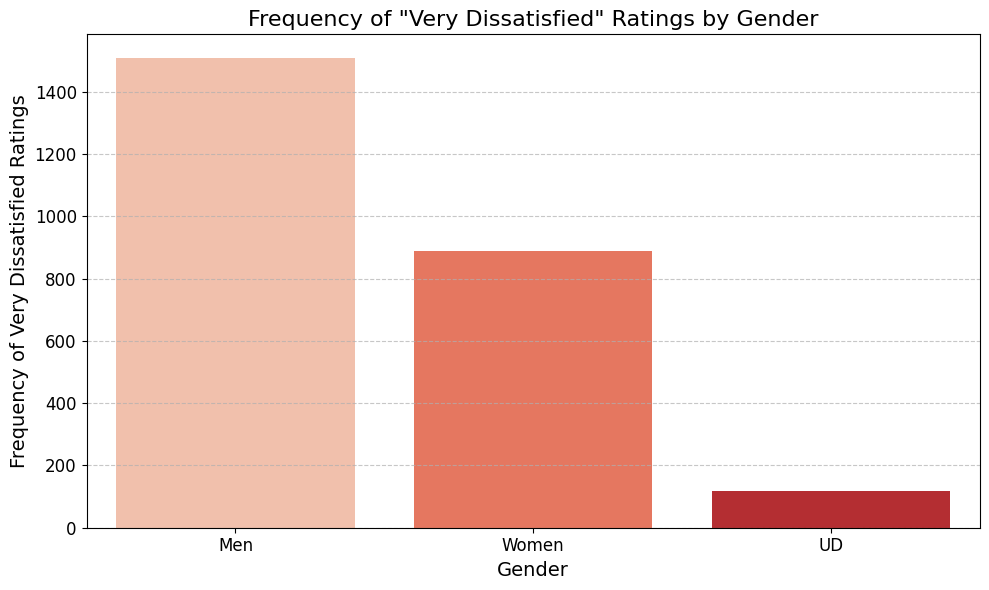

In [16]:
##Plot for "Very Dissatisfied" with respect to Gender
very_dissatisfied_data = df[df['Overall Rating'] == 'Very Dissatisfied']
plt.figure(figsize=(10, 6))
sns.countplot(data=very_dissatisfied_data, x='Gender', palette='Reds')
plt.title('Frequency of "Very Dissatisfied" Ratings by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Frequency of Very Dissatisfied Ratings', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
##Location vs Career Growth
contingency_table = pd.crosstab(df['Location'], df['Career Growth'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-Square Statistic: 27.162960229474848
P-value: 0.5093868011284568
Degrees of Freedom: 28
Expected Frequencies:
[[ 258.04653324  565.64592931  941.75215826  374.61964306 1059.93573613]
 [ 255.14350974  559.28241261  931.15744648  370.40517208 1048.0114591 ]
 [ 256.67566103  562.64093531  936.74909992  372.62947621 1054.30482753]
 [ 258.53037049  566.70651543  943.51794356  375.3220549  1061.92311564]
 [ 269.49734815  590.74646742  983.54241028  391.24338973 1106.97038442]
 [ 265.22345244  581.37795672  967.94464016  385.03875189 1089.41519879]
 [ 254.17583524  557.16124037  927.62587589  369.00034842 1044.03670009]
 [ 265.70728969  582.43854284  969.71042546  385.74116372 1091.4025783 ]]


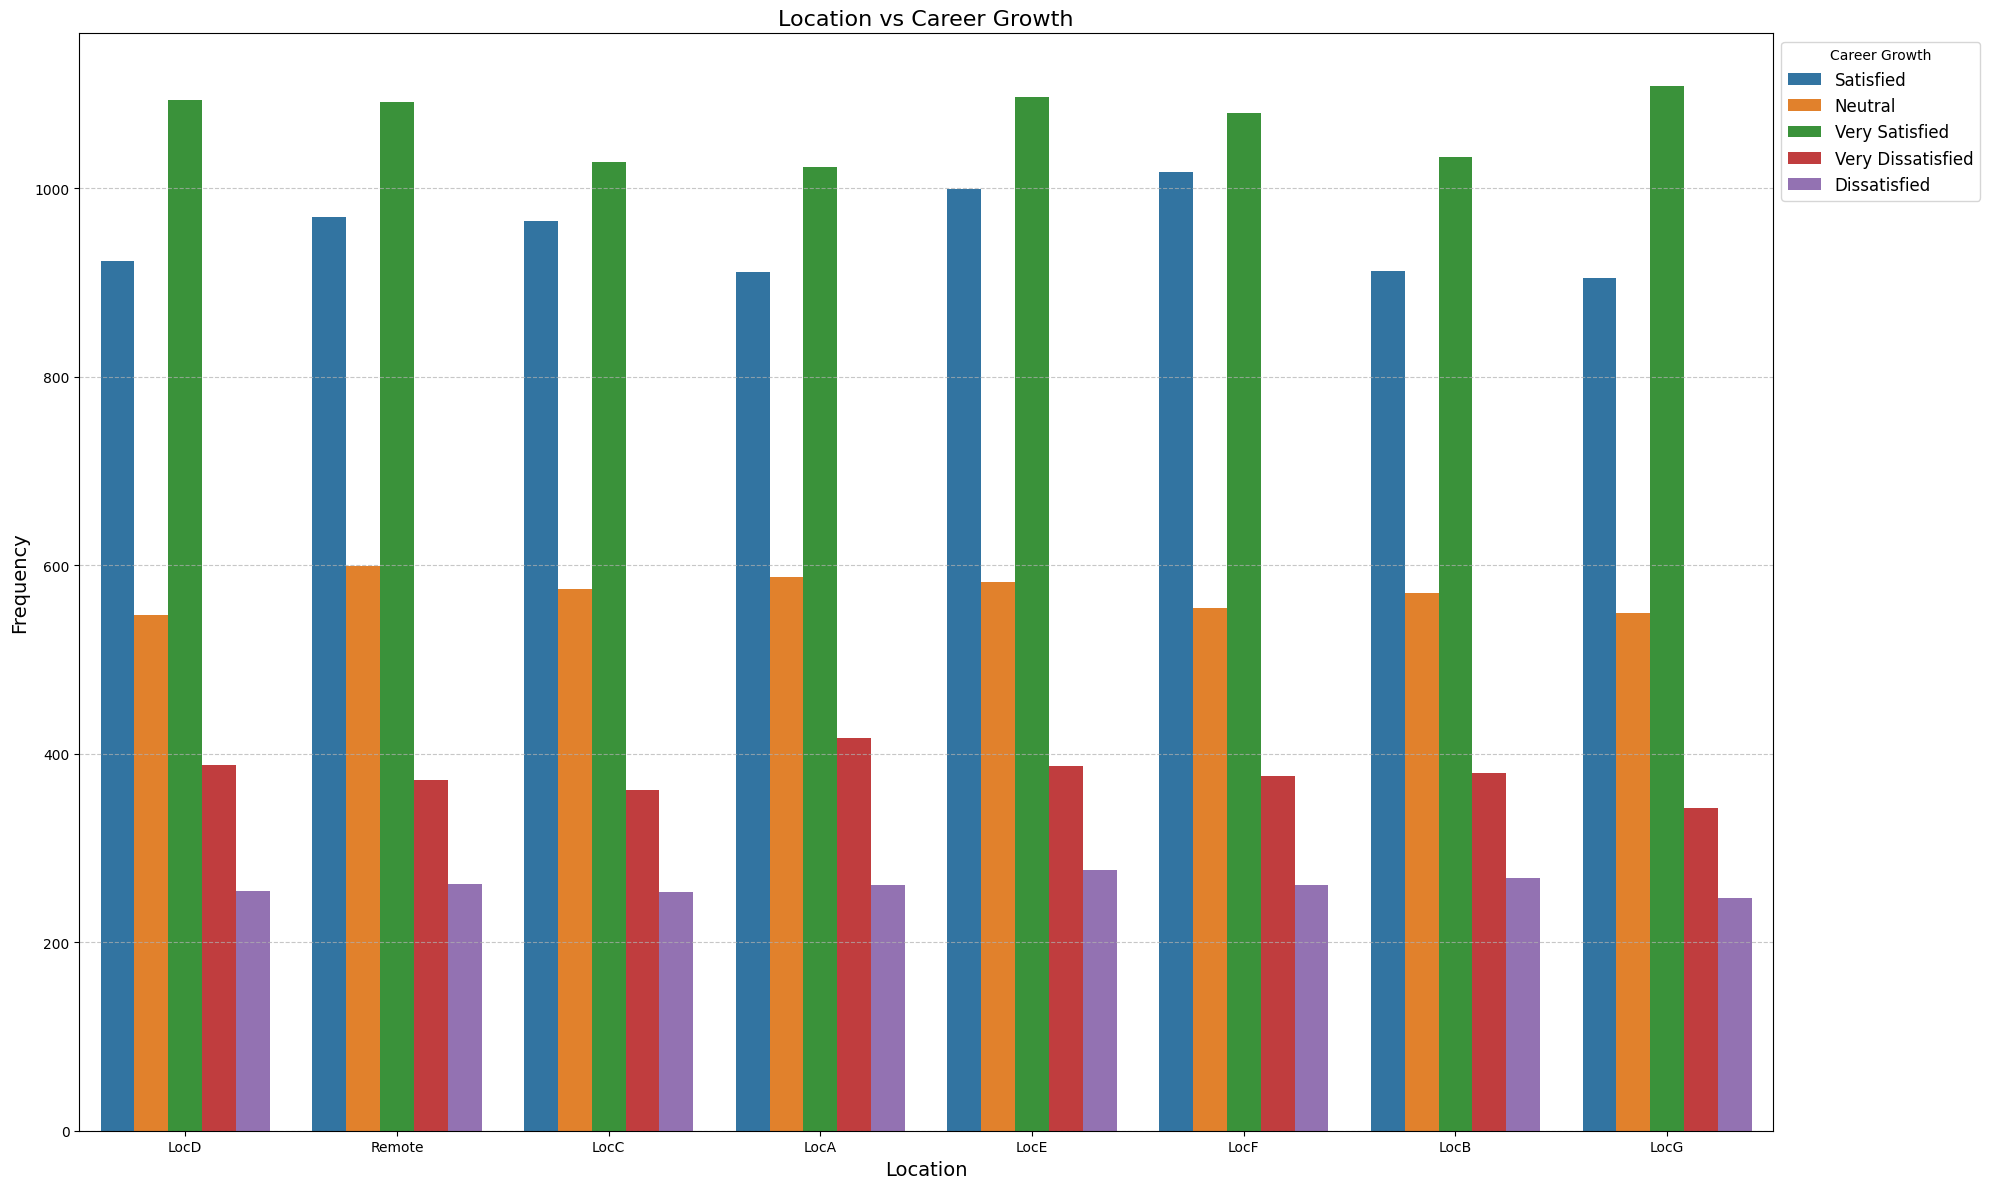

In [18]:
##Plot for location vs Career Growth
plt.figure(figsize=(20,12))
sns.countplot(data=df, x='Location', hue='Career Growth')
plt.title('Location vs Career Growth', fontsize=16)
plt.xlabel('Location', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Career Growth', loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  
plt.show()

In [19]:
##Location vs Career Growth
contingency_table = pd.crosstab(df['Location'], df['Compensation and Benefits'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-Square Statistic: 29.041303966775303
P-value: 0.41043510762108093
Degrees of Freedom: 28
Expected Frequencies:
[[508.66013704 890.83659169 670.94576284 565.76981147 563.78769695]
 [502.9377105  880.81468004 663.39762301 559.40490109 557.44508536]
 [505.95788007 886.1040223  667.38136348 562.76415934 560.79257481]
 [509.6138748  892.5069103  672.20378615 566.83062986 564.84479889]
 [531.23193063 930.36746545 700.71898107 590.87584685 588.80577601]
 [522.80724711 915.6129844  689.60644187 581.50528435 579.46804227]
 [501.03023499 877.47404282 660.8815764  557.28326429 555.3308815 ]
 [523.76098486 917.28330301 690.86446518 582.56610274 580.52514421]]


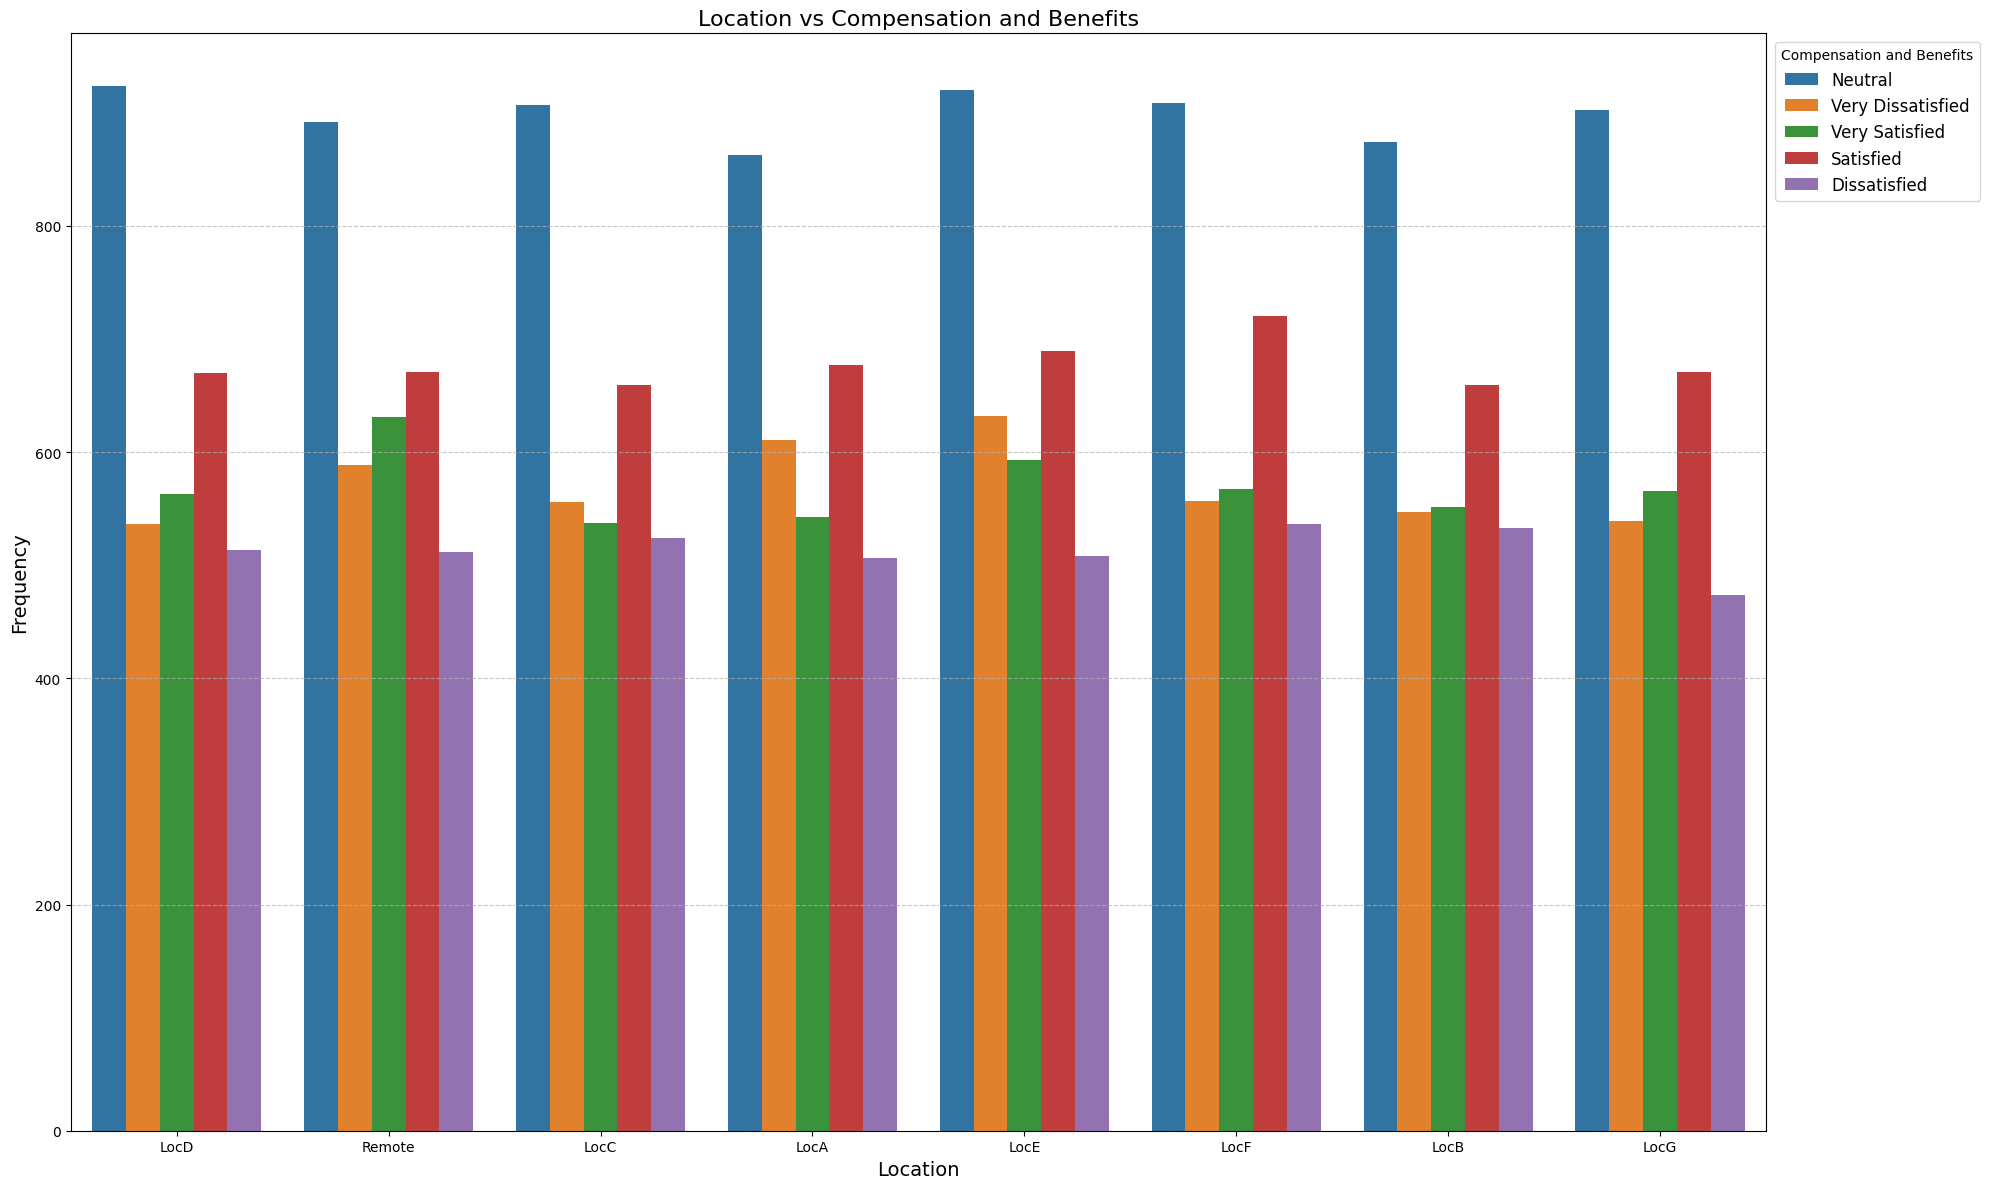

In [20]:
##Plot for Location vs Compensation and Benefits
plt.figure(figsize=(20,12))
sns.countplot(data=df, x='Location', hue='Compensation and Benefits')
plt.title('Location vs Compensation and Benefits', fontsize=16)
plt.xlabel('Location', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Compensation and Benefits', loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  
plt.show()

In [21]:
##Location vs Work-life balance

contingency_table = pd.crosstab(df['Location'], df['Work-life Balance'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-Square Statistic: 29.362199490595835
P-value: 0.3943332295661362
Degrees of Freedom: 28
Expected Frequencies:
[[ 240.70303124  588.68801053  997.87077542  333.11912044 1039.61906237]
 [ 237.99512214  582.06527041  986.6447292   329.37153033 1027.92334792]
 [ 239.42429639  585.56060547  992.56958693  331.34942511 1034.0960861 ]
 [ 241.15434943  589.79180055  999.74178313  333.74371879 1041.56834811]
 [ 251.38422825  614.811041   1042.15129108  347.90128141 1085.75215826]
 [ 247.3975843   605.06089582 1025.62405637  342.38399597 1068.53346754]
 [ 237.09248577  579.85769037  982.90271379  328.12233363 1024.02477643]
 [ 247.84890248  606.16468584 1027.49506407  343.00859432 1070.48275328]]


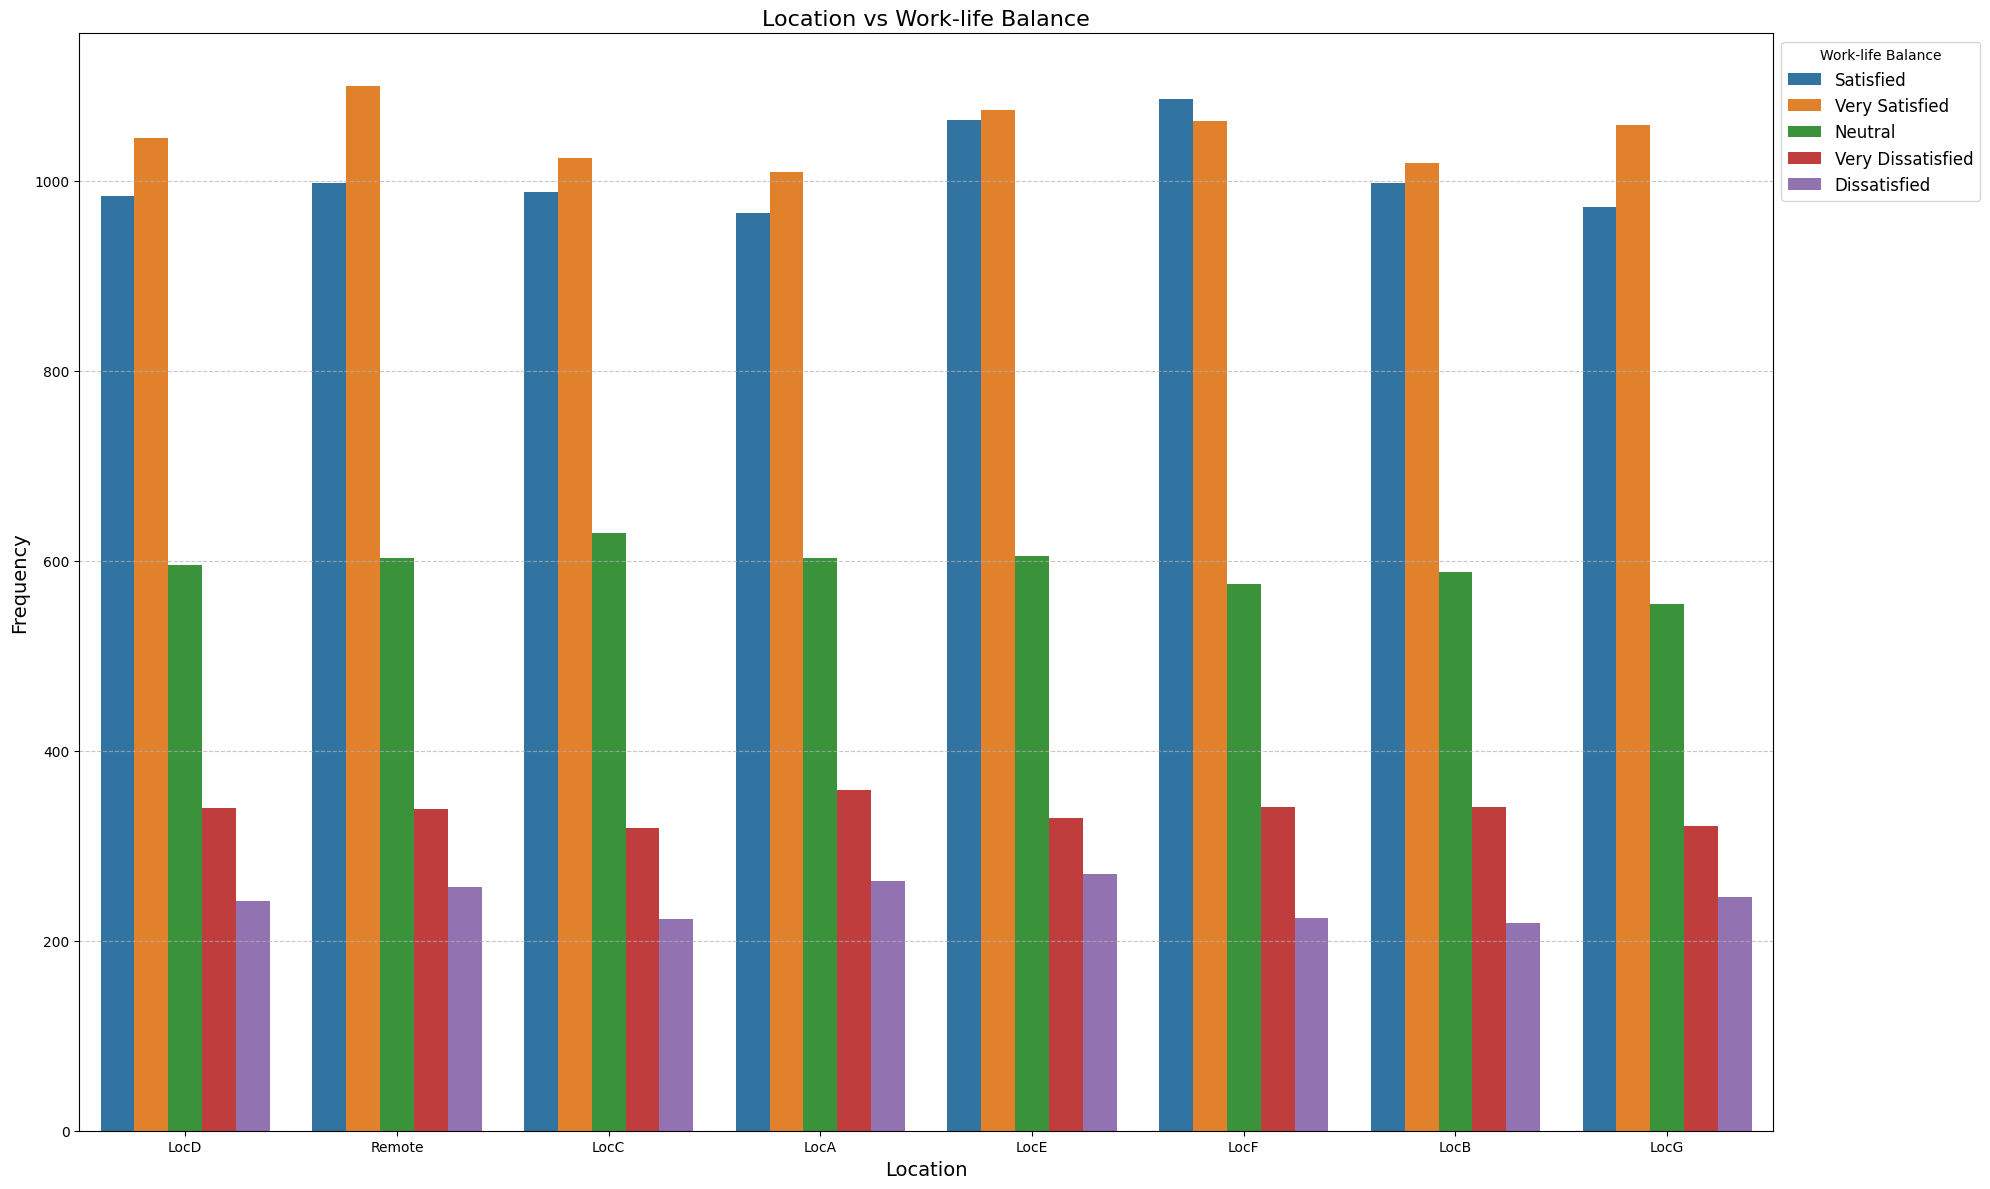

In [ ]:
##Plot for Location vs Work-lief balance

plt.figure(figsize=(20,12))
sns.countplot(data=df, x='Location', hue='Work-life Balance')
plt.title('Location vs Work-life Balance', fontsize=16)
plt.xlabel('Location', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Work-life Balance', loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()  
plt.show()

In [23]:
##Label Encoding for Overall Rating, Career Growth, Compensation and Benefits, Work-life Balance
rating_map = {
    "Very Dissatisfied": 1,
    "Dissatisfied": 2,
    "Neutral": 3,
    "Satisfied": 4,
    "Very Satisfied": 5
}
rating_cols = ['Overall Rating', 'Career Growth', 'Compensation and Benefits', 'Work-life Balance']
for col in rating_cols:
    df[col] = df[col].map(rating_map)

In [24]:
##Pivot table for Overall Ratings by Location and Gender
pivot_table = df.pivot_table(values='Overall Rating', index='Location', columns='Gender', aggfunc='mean')
print("Pivot Table: Overall Ratings by Location and Gender")
print(pivot_table)

Pivot Table: Overall Ratings by Location and Gender
Gender         Men      N.D.        UD     Women
Location                                        
LocA      3.542422  5.000000  3.484848  3.800863
LocB      3.653037  3.333333  3.593750  3.778887
LocC      3.638404       NaN  3.564103  3.800958
LocD      3.605988  3.666667  3.618557  3.835655
LocE      3.636728  5.000000  3.330097  3.765615
LocF      3.642983  4.250000  3.698113  3.815041
LocG      3.660296       NaN  3.484536  3.840195
Remote    3.693642       NaN  3.572650  3.810773


In [25]:
##Question 2 - calculation of correlation of overall rating w.r.t Career Growth, Compensation and Benefits, Work-life Balance
spearman_corr = df[['Career Growth', 'Compensation and Benefits', 'Work-life Balance', 'Overall Rating']].corr(method='spearman')
print("Spearman Correlation:")
print(spearman_corr)

Spearman Correlation:
                           Career Growth  Compensation and Benefits  \
Career Growth                   1.000000                   0.689695   
Compensation and Benefits       0.689695                   1.000000   
Work-life Balance               0.740509                   0.644953   
Overall Rating                  0.686986                   0.631775   

                           Work-life Balance  Overall Rating  
Career Growth                       0.740509        0.686986  
Compensation and Benefits           0.644953        0.631775  
Work-life Balance                   1.000000        0.654926  
Overall Rating                      0.654926        1.000000  


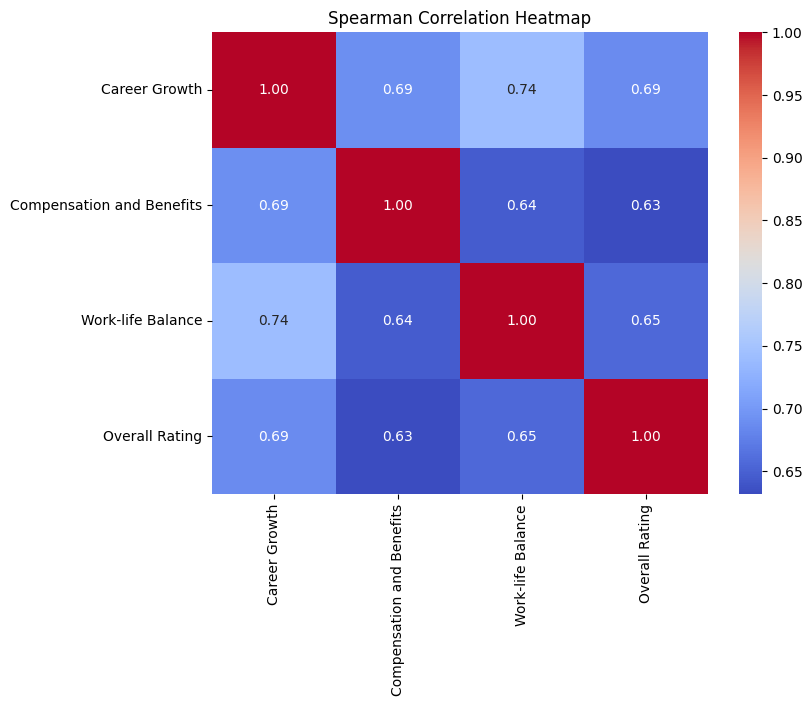

In [26]:
##Plot for correlation
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Spearman Correlation Heatmap")
plt.show()

In [60]:
##Career Growth vs Gender
contingency_table = pd.crosstab(df['Career Growth'], df['Gender'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-Square Statistic: 193.39395034654467
P-value: 7.511486685818444e-35
Degrees of Freedom: 12
Expected Frequencies:
[[1.57445612e+03 1.52189230e+00 9.74011072e+01 1.35062088e+03]
 [1.08452120e+03 1.04831404e+00 6.70920986e+01 9.30338392e+02]
 [2.37730378e+03 2.29793659e+00 1.47067942e+02 2.03933034e+03]
 [3.95800774e+03 3.82586814e+00 2.44855561e+02 3.39531083e+03]
 [4.45471116e+03 4.30598893e+00 2.75583291e+02 3.82139956e+03]]


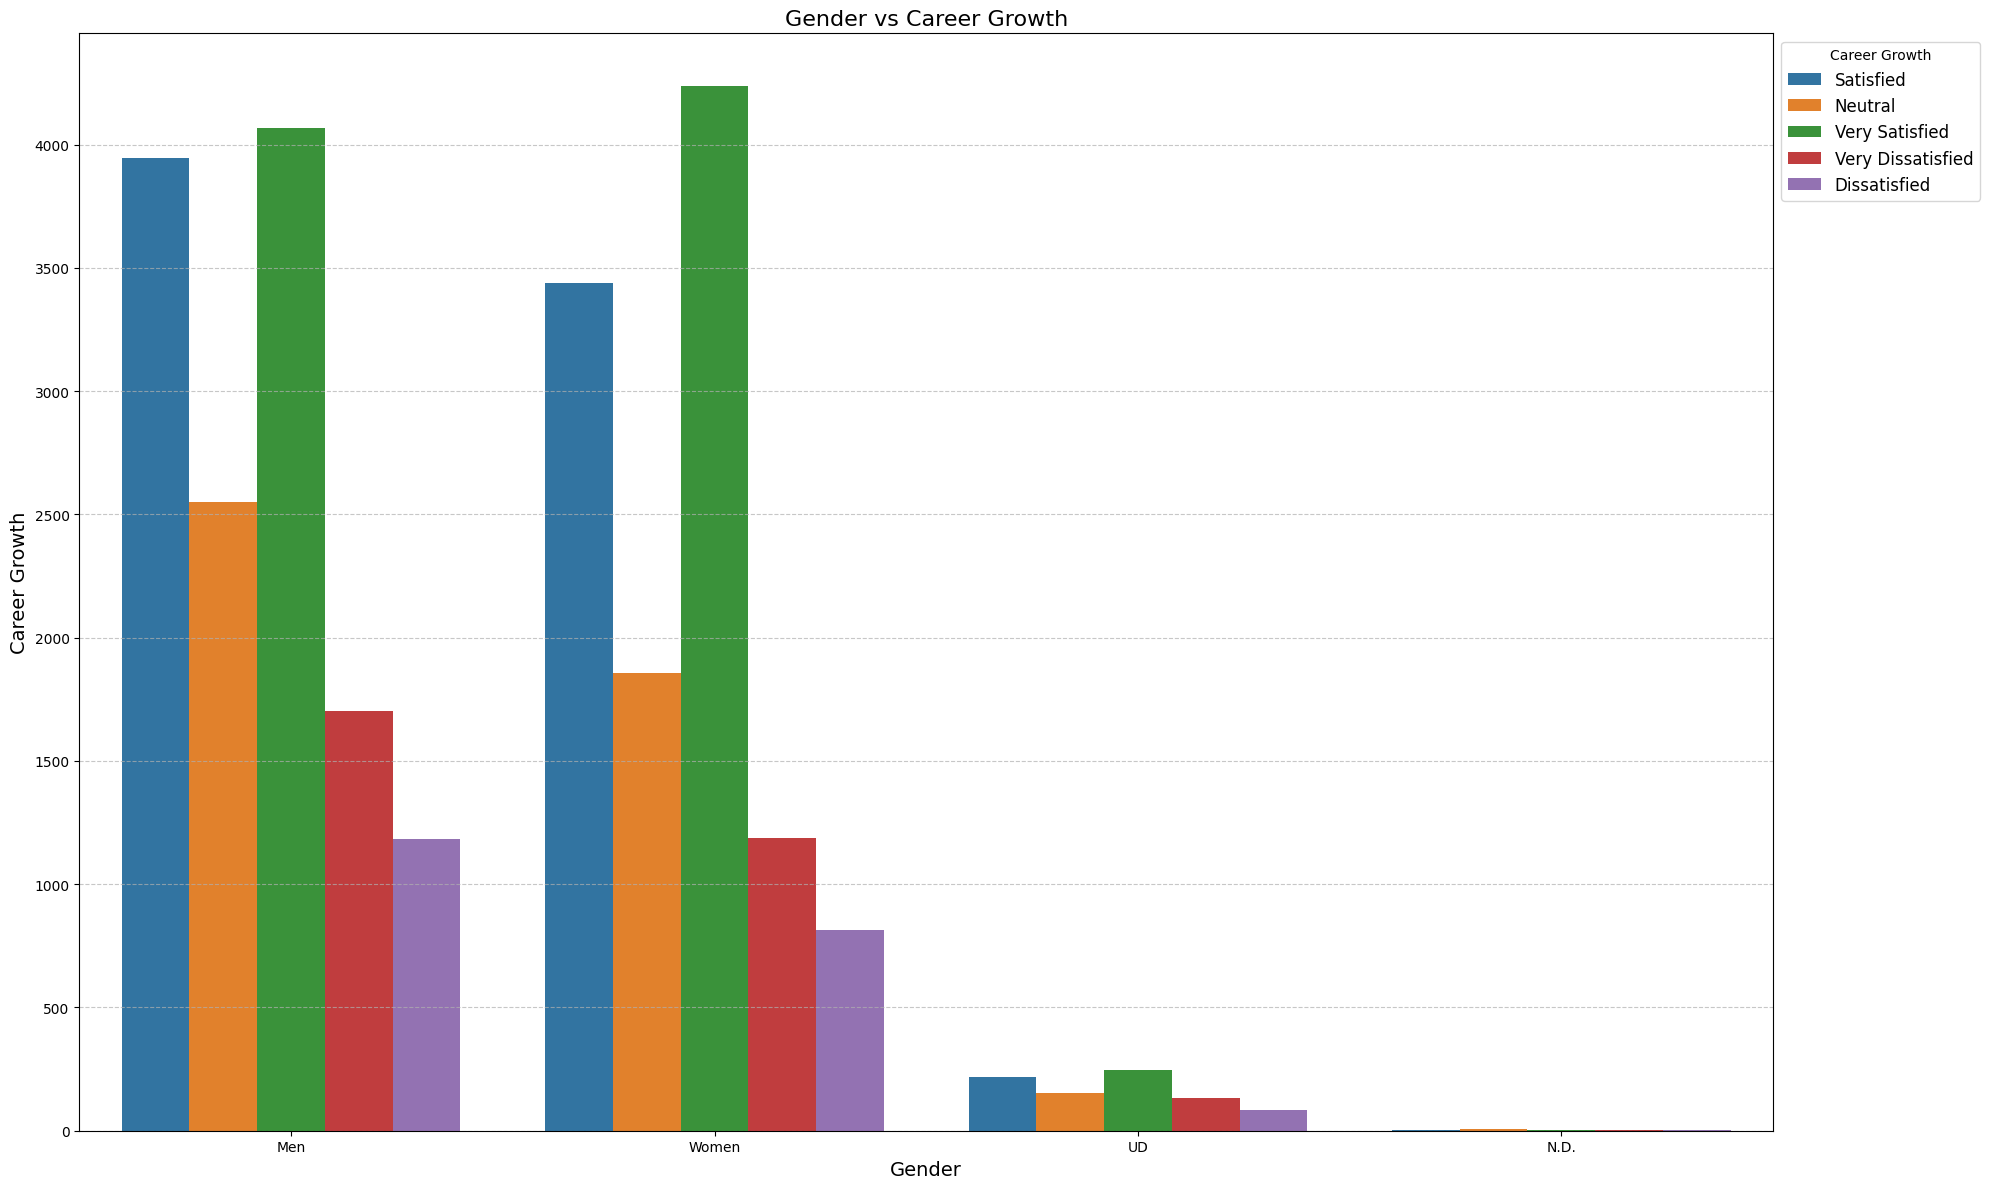

In [61]:
##Plot for Career Growth vs Gender
reverse_rating_map = {v: k for k, v in rating_map.items()}
for col in rating_cols:
    df[f"{col}_decoded"] = df[col].map(reverse_rating_map)
plt.figure(figsize=(20, 12))
sns.countplot(data=df, x='Gender', hue='Career Growth_decoded') 
plt.title('Gender vs Career Growth', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Career Growth', fontsize=14)
plt.legend(title='Career Growth', loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  
plt.show()


In [62]:
##Overall Rating vs Gender
contingency_table = pd.crosstab(df['Overall Rating'], df['Gender'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-Square Statistic: 165.2693129345351
P-value: 4.421916069329318e-29
Degrees of Freedom: 12
Expected Frequencies:
[[1.30944350e+03 1.26572723e+00 8.10065425e+01 1.12328423e+03]
 [9.52795865e+02 9.20986412e-01 5.89431303e+01 8.17340018e+02]
 [2.43874089e+03 2.35732260e+00 1.50868646e+02 2.09203314e+03]
 [4.40004255e+03 4.25314545e+00 2.72201309e+02 3.77450300e+03]
 [4.34797720e+03 4.20281832e+00 2.68980372e+02 3.72983961e+03]]


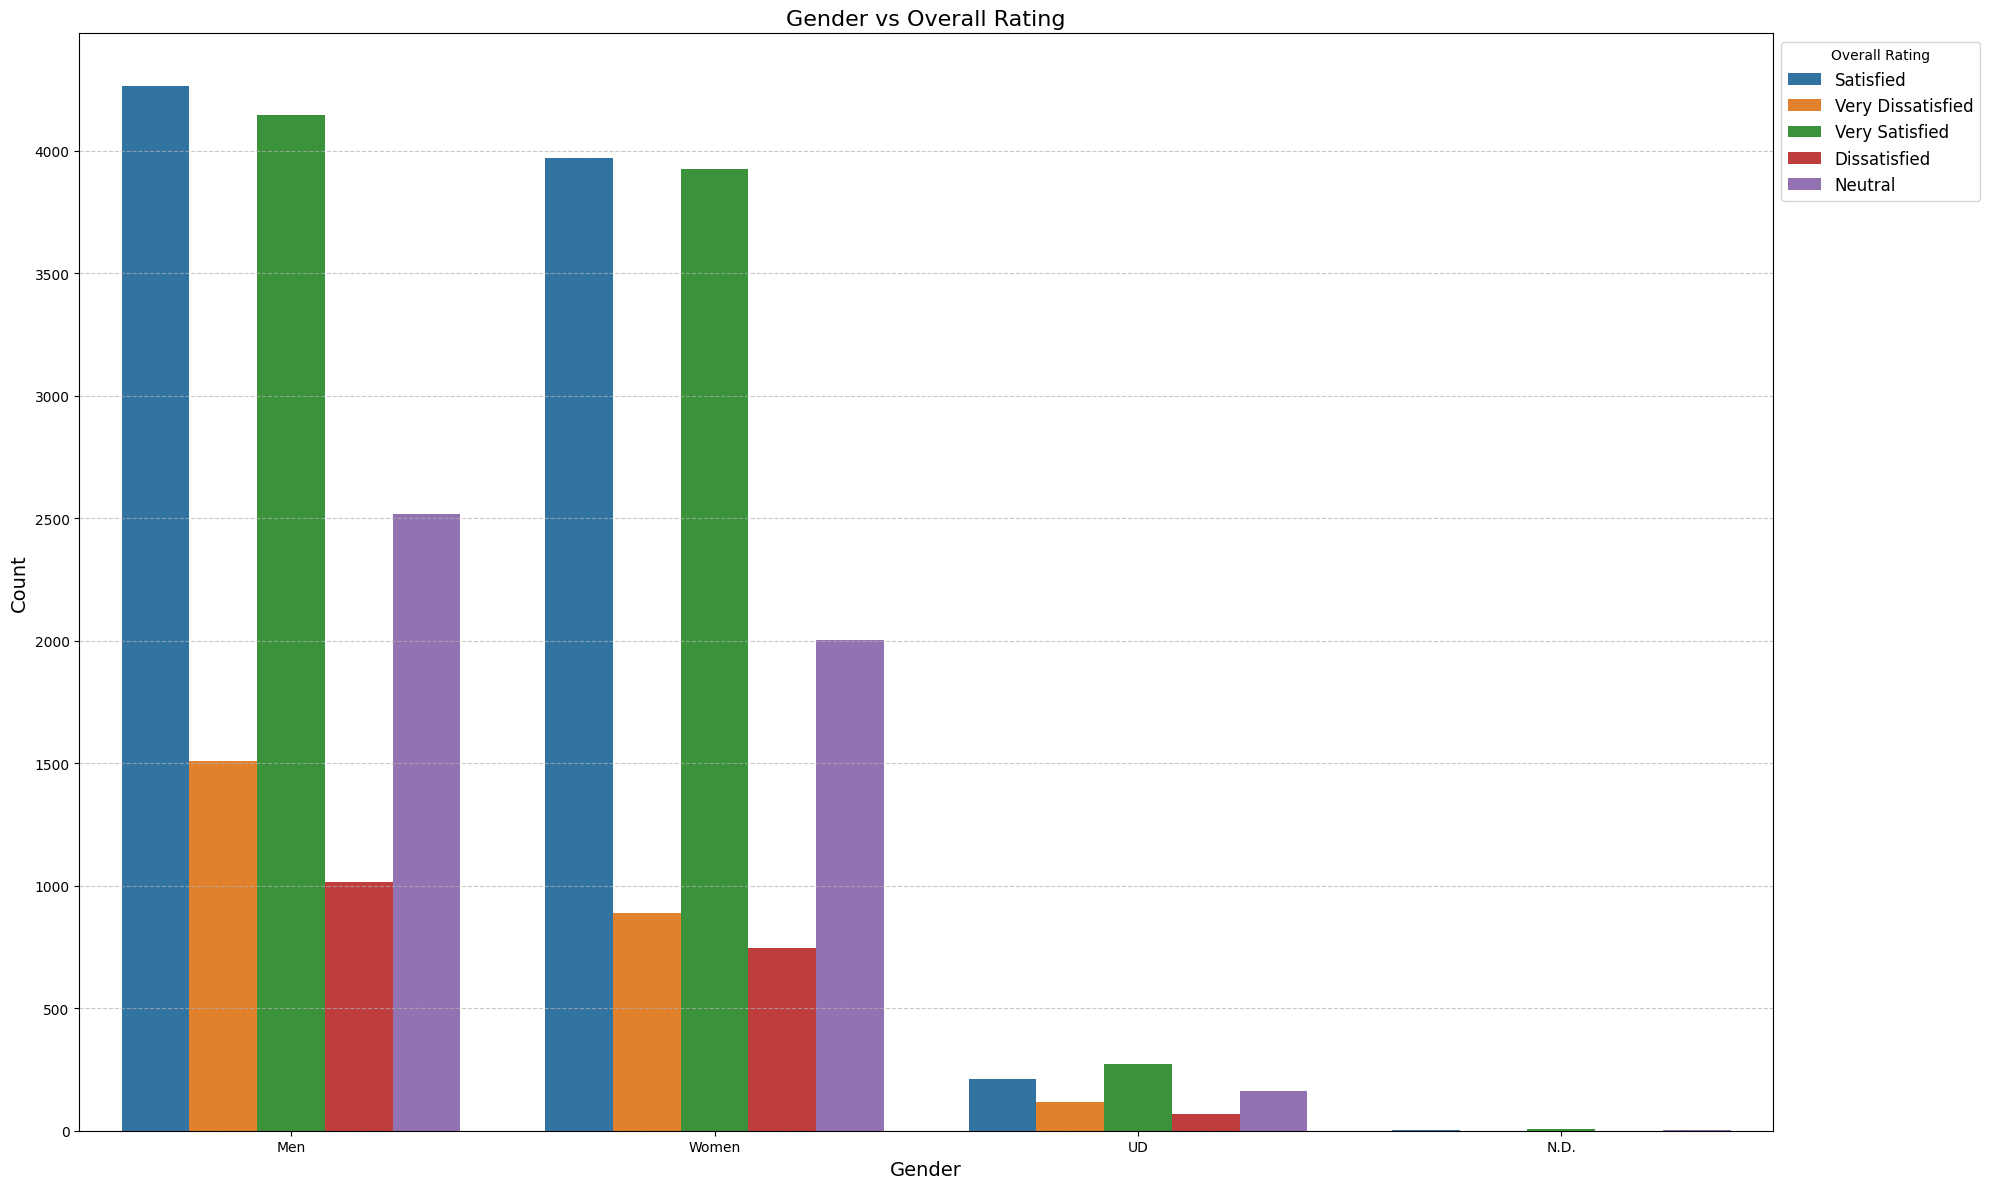

In [63]:
##Plot forOverall Rating vs Gender
reverse_rating_map = {v: k for k, v in rating_map.items()}
for col in rating_cols:
    df[f"{col}_decoded"] = df[col].map(reverse_rating_map)
plt.figure(figsize=(20, 12))
sns.countplot(data=df, x='Gender', hue='Overall Rating_decoded')  
plt.title('Gender vs Overall Rating', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Overall Rating', loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  
plt.show()


In [64]:
df['Level'] = df['Level'].str.strip().str.title() 

In [65]:
##Level vs Gender
contingency_table = pd.crosstab(df['Level'], df['Gender'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-Square Statistic: 2519.1809627358434
P-value: 0.0
Degrees of Freedom: 6
Expected Frequencies:
[[7.60622667e+03 7.35228988e+00 4.70546553e+02 6.52487449e+03]
 [4.35474569e+03 4.20936085e+00 2.69399094e+02 3.73564585e+03]
 [1.48802764e+03 1.43834927e+00 9.20543533e+01 1.27647966e+03]]


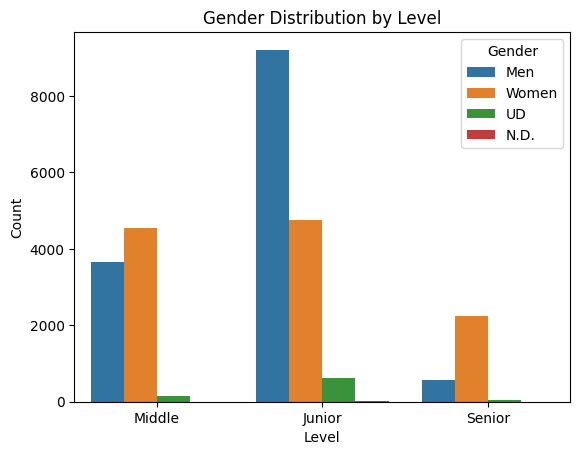

In [66]:
##Plot for Gender Distribution by Level
sns.countplot(x='Level', hue='Gender', data=df)
plt.title('Gender Distribution by Level')
plt.xlabel('Level')
plt.ylabel('Count')
plt.show()

In [67]:
##Question 3 - To calculate which category has more dissatisfaction percentage
df['Date Of Joining'] = pd.to_datetime(df['Date Of Joining'], format='%d-%b-%y', errors='coerce')
df['Duration'] = (datetime.now() - df['Date Of Joining']).dt.days / 365.25
df['Class'] = df['Duration'].apply(
    lambda x: 'High Tenured (15+ Years)' if x >= 15 else ('Covid Joiner(2020+)' if x <= 4 else 'Others')
)
df['Very Dissatisfied'] = df['Overall Rating'] == 1
df['Dissatisfied'] = df['Overall Rating'] == 2
df['Dissatisfied_Associates'] = df['Very Dissatisfied'] | df['Dissatisfied']
total_associates = df['EmpID'].count()
total_dissatisfied = df['Dissatisfied_Associates'].sum()
dissatisfaction_percentage = (total_dissatisfied / total_associates) * 100
very_dissatisfied_percentage = (df['Very Dissatisfied'].sum() / total_associates) * 100
dissatisfied_percentage = (df['Dissatisfied'].sum() / total_associates) * 100
print(f"Overall Dissatisfaction Percentage: {dissatisfaction_percentage:.2f}%")
print(f"Very Dissatisfied Percentage: {very_dissatisfied_percentage:.2f}%")
print(f"Dissatisfied Percentage: {dissatisfied_percentage:.2f}%")
dissatisfaction_summary = df.groupby('Class').agg(
    Total_Associates=('EmpID', 'count'),
    Very_Dissatisfied_Associates=('Very Dissatisfied', 'sum'),
    Dissatisfied_Associates=('Dissatisfied', 'sum'),
    Dissatisfied_Associates_Combined=('Dissatisfied_Associates', 'sum')
).reset_index()
dissatisfaction_summary['Very_Dissatisfied_Rate'] = (dissatisfaction_summary['Very_Dissatisfied_Associates'] / dissatisfaction_summary['Total_Associates']) * 100
dissatisfaction_summary['Dissatisfied_Rate'] = (dissatisfaction_summary['Dissatisfied_Associates'] / dissatisfaction_summary['Total_Associates']) * 100
dissatisfaction_summary['Dissatisfaction_Rate'] = (dissatisfaction_summary['Dissatisfied_Associates_Combined'] / dissatisfaction_summary['Total_Associates']) * 100

aggregated_summary = {
    'Total_Associates': total_associates,
    'Total_Dissatisfied_Associates': total_dissatisfied,
    'Dissatisfaction_Percentage': dissatisfaction_percentage,
    'Very_Dissatisfied_Percentage': very_dissatisfied_percentage,
    'Dissatisfied_Percentage': dissatisfied_percentage
}
dissatisfaction_summary

Overall Dissatisfaction Percentage: 16.81%
Very Dissatisfied Percentage: 9.74%
Dissatisfied Percentage: 7.07%


,Class,Total_Associates,Very_Dissatisfied_Associates,Dissatisfied_Associates,Dissatisfied_Associates_Combined,Very_Dissatisfied_Rate,Dissatisfied_Rate,Dissatisfaction_Rate
0,Covid Joiner(2020+),5027,452,356,808,8.991446,7.081759,16.073205
1,High Tenured (15+ Years),6546,657,440,1097,10.036664,6.721662,16.758326
2,Others,14293,1410,1034,2444,9.864969,7.234311,17.099279


In [68]:
#Question 4 - Sentiment Analysis
df['Comments'] = df['Comments'].astype(str)
def sentimentanalysis(comment):
    blob = TextBlob(comment)
    return blob.sentiment.polarity
df['Sentiment Polarity'] = df['Comments'].apply(sentimentanalysis)
df['Categorry of sentiment'] = df['Sentiment Polarity'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)
sentiment_summary = df['Categorry of sentiment'].value_counts().reset_index()
sentiment_summary.columns = ['Sentiment', 'Count']
print(sentiment_summary)

  Sentiment  Count
0   Neutral  13174
1  Positive  10198
2  Negative   2494


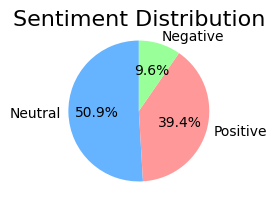

In [69]:
##Pie chart for sentiment analysis
sentiment_summary = df['Categorry of sentiment'].value_counts().reset_index()
sentiment_summary.columns = ['Sentiment', 'Count']
plt.figure(figsize=(2,2))
plt.pie(sentiment_summary['Count'], labels=sentiment_summary['Sentiment'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999', '#99ff99'])
plt.title('Sentiment Distribution', fontsize=16)
plt.axis('equal')  
plt.show()

In [70]:

df['Comments'] = df['Comments'].astype(str)
words_to_remove = {'good', 'life', '0', 'better', 'job', 'happy', 'work', 'place', 'company',
                   '\n', 'companyx', 'nothing', 'working', 'like', 'great', 'career'}
stop_words = list(set(stopwords.words('english')).union(words_to_remove))

def preprocessing(text):
    text = text.lower() 
    text = text.translate(str.maketrans('', '', string.punctuation))  
    return text

df['Processed_Comments'] = df['Comments'].apply(preprocessing)
vectorizer = CountVectorizer(ngram_range=(2, 3), stop_words=stop_words)
X = vectorizer.fit_transform(df['Processed_Comments'])
ngram_counts = X.toarray().sum(axis=0)
ngram_list = vectorizer.get_feature_names_out()
ngram_freq = dict(zip(ngram_list, ngram_counts))
top_10_themes = Counter(ngram_freq).most_common(10)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(ngram_freq)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Top Themes", fontsize=16)
plt.show()
print("Top 10 Themes:")
for theme, count in top_10_themes:
    print(f"{theme}: {count}")


MemoryError: Unable to allocate 18.9 GiB for an array with shape (25866, 98227) and data type int64